In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os
import sys

from pathlib import Path
import shutil

sys.path.insert(0, str(Path("../JAMDiFF_library").resolve()))
from get_JAM_DiFF import get_JAM_DiFF_dict

import pickle

Settings

In [ ]:
c = 1/2

fit_name = "Default"

if_generate_grids = True

N_replicas = 969

N_cores = 16

Read Files

In [3]:
Main.eval('using Distributed')
Main.eval(f'addprocs({N_cores})')

fitting_root = "../"
def include(name):
    path = os.path.join(fitting_root, name)
    Main.eval(f'@everywhere include(raw"{path}")')

card_name = fit_name.removesuffix(".jl")
include(f"Cards/{card_name}.jl")

# PDF
include("Collinear_PDF/pdf.jl")
# Core
include("Core/constants.jl")
include("Core/strong coupling.jl")
# Numerical
include("Numerical/FastGK.jl")
# DiFF 
include("DiFF_EEC/DiFF_EEC.jl")
include("Processes/SIDIS/SIDIS_AUT.jl")
include("Processes/ee/ee_AUT.jl")

wdir = Main.eval("wdir")


      From worker 16:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 16:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 15:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 15:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 15:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF23-transversity_lo_0000.dat
      From worker 15:	JAMDiFF23-transversity_lo PDF set, member #0, version 1; LHAPDF ID = 1
      From worker 2:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/CT18NLO/CT18NLO_0000.dat
      From worker 2:	CT18NLO PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 2:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF23-t

Generate JAM DiFFs 

In [ ]:
z_array=np.linspace(0.19,0.99,20)  
Mh_array=np.linspace(0.28,2.05,50)
Q_array = [2,7,8.5,10]

In [5]:
kinds = ["D1", "H1a"]
mu_array = c*np.array(Q_array)
if if_generate_grids:

    dict_raw_DiFF = get_JAM_DiFF_dict(
        z_array=z_array, Mh_array=Mh_array, mu_array=mu_array, kinds=kinds, wdir=wdir
    )

    with open("../Grids/dict_raw_DiFF.pkl", "wb") as f:
        pickle.dump(dict_raw_DiFF, f, protocol=pickle.HIGHEST_PROTOCOL)

else:
    with open("../Grids/dict_raw_DiFF.pkl", "rb") as f:
        dict_raw_DiFF = pickle.load(f)

keys = [k for k in dict_raw_DiFF.keys() if isinstance(k, tuple)]
Main.dict_raw_DiFF = {k: v for k, v in dict_raw_DiFF.items()}
Main.eval('''let payload = dict_raw_DiFF
    @everywhere global dict_raw_DiFF = $payload
end''')


generating D1 at Q2 = 4.368099999999999 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating D1 at Q2 = 25.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating D1 at Q2 = 100.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating D1 at Q2 = 400.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating D1 at Q2 = 1600.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating D1 at Q2 = 2500.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating H1a at Q2 = 4.368099999999999 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating H1a at Q2 = 25.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF_julia/JAMDiFF_library/results/wLQCD
969/969
generating H1a at Q2 = 100.0 from /home/maxzhang/UCLA_QCD_fitter/DiFF

Construct JAM DiFF Interpolators

In [6]:
all_replica_ids = sorted({k[2] for k in keys if k[2] > 0})
N_total = len(all_replica_ids)

n_selected = min(int(N_replicas), N_total)
replica_ids = np.random.choice(all_replica_ids, size=n_selected, replace=False)
replica_ids = np.sort(np.concatenate(([0], np.asarray(replica_ids, dtype=int))))
selected_keys = [k for k in keys if k[2] in replica_ids]

Main.selected_keys = selected_keys
Main.eval('''let payload = selected_keys
    @everywhere global selected_keys = $payload
end''')

include("Grids/initialization.jl")

Test & Warm Up SIDIS AUT

In [7]:
chi_deg = 10.0
chi = np.deg2rad(chi_deg)

Main.a_D1 = 0.1
Main.b_D1 = 0.1
Main.a_H1a = 0.1
Main.b_H1a = 0.1
Main.eval('''@everywhere begin
    global a_D1 = 0.1
    global b_D1 = 0.1
    global a_H1a = 0.1
    global b_H1a = 0.1
end''')

value = Main.SIDIS_EEC_AUT(
    chi=chi, # chi in radians
    x=0.1,   # x
    Q=20.0,  # Q
    mu=10.0, # scale
    rep=0,   # replica id
)

warmup_values, warmup_time = Main.SIDIS_EEC_AUT_pmap(
    chi_array=[chi, chi],
    x_array=[0.1, 0.1],
    Q_array=[20.0, 20.0],
    mu_array=[10.0, 10.0],
    rep=[0, 0],
)

display(value)
display((len(warmup_values), warmup_time))

0.025132710895797824

(2, 2.29114122)

SIDIS AUT Replica Generation And Plotting

In [8]:
import time
from IPython.display import clear_output

results_dir = Path("AUT_EEC_results")
results_dir.mkdir(exist_ok=True)

def _format_seconds(seconds):
    seconds = max(float(seconds), 0.0)
    if seconds < 60:
        return f"{seconds:.1f}s"
    minutes, sec = divmod(int(round(seconds)), 60)
    if minutes < 60:
        return f"{minutes}m {sec:02d}s"
    hours, minutes = divmod(minutes, 60)
    return f"{hours}h {minutes:02d}m {sec:02d}s"

def set_diff_coeffs(a, b):
    a = float(a)
    b = float(b)
    Main.a_D1 = a
    Main.b_D1 = b
    Main.a_H1a = a
    Main.b_H1a = b
    Main.eval(
        f'''@everywhere begin
            global a_D1 = {a}
            global b_D1 = {b}
            global a_H1a = {a}
            global b_H1a = {b}
        end'''
    )

def sidis_aut_filename(a, b, x, Q, fit_order="LO"):
    return results_dir / f"AUT_EEC_SIDIS_a{a:.2f}_b{b:.2f}_x{x:.2f}_Q{int(Q)}_{fit_order}.xlsx"

def generate_sidis_aut_results(*, x_list, Q_list, coeffs, nreps_rand, fit_order="LO", chi_deg_array=None):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")
    if chi_deg_array is None:
        chi_deg_array = np.linspace(1, 30, 30)

    nreps_rand = min(int(nreps_rand), len(all_replica_ids))
    rep_DiFF = np.asarray(np.random.choice(all_replica_ids, size=nreps_rand, replace=False), dtype=int)
    total_jobs = len(x_list) * len(Q_list)
    jobs_done = 0
    t0_all = time.perf_counter()

    set_diff_coeffs(coeffs[0], coeffs[1])

    for x in x_list:
        for Q in Q_list:
            chi_deg_valid = []
            chi_valid = []
            for chi_deg in chi_deg_array:
                chi = np.deg2rad(chi_deg)
                z = (1 - np.cos(chi)) / 2
                if np.sqrt(z) * Q > 7:
                    continue
                chi_deg_valid.append(float(chi_deg))
                chi_valid.append(float(chi))

            n_chi = len(chi_valid)
            chi_array = np.asarray(chi_valid, dtype=float)
            x_array = np.full(n_chi, float(x), dtype=float)
            Q_array = np.full(n_chi, float(Q), dtype=float)
            mu_array = np.full(n_chi, float(c * Q), dtype=float)

            AUT_EEC_thy_central, _ = Main.SIDIS_EEC_AUT_pmap(
                chi_array=chi_array,
                x_array=x_array,
                Q_array=Q_array,
                mu_array=mu_array,
                rep=np.zeros(n_chi, dtype=int),
            )

            if nreps_rand > 0:
                rep_array = np.repeat(rep_DiFF, n_chi)
                chi_array_flat = np.tile(chi_array, nreps_rand)
                x_array_flat = np.tile(x_array, nreps_rand)
                Q_array_flat = np.tile(Q_array, nreps_rand)
                mu_array_flat = np.tile(mu_array, nreps_rand)

                AUT_EEC_thy_arr_flat, _ = Main.SIDIS_EEC_AUT_pmap(
                    chi_array=chi_array_flat,
                    x_array=x_array_flat,
                    Q_array=Q_array_flat,
                    mu_array=mu_array_flat,
                    rep=rep_array,
                )
                AUT_EEC_thy_arr_all = np.asarray(AUT_EEC_thy_arr_flat, dtype=float).reshape(nreps_rand, n_chi)
                AUT_EEC_thy_std = np.std(AUT_EEC_thy_arr_all, axis=0)
            else:
                AUT_EEC_thy_std = np.zeros(n_chi, dtype=float)

            _CHI = chi_deg_valid
            AUT_EEC_thy_central = np.asarray(AUT_EEC_thy_central, dtype=float)
            jobs_done += 1
            elapsed = time.perf_counter() - t0_all
            avg_time = elapsed / jobs_done
            eta = avg_time * (total_jobs - jobs_done)
            clear_output(wait=True)
            print(f"[{jobs_done}/{total_jobs}] x={x:.2f}, Q={Q:g} | remaining={_format_seconds(eta)}")

            df = pd.DataFrame()
            df["CHI"] = _CHI
            df["AUT_central"] = AUT_EEC_thy_central
            df["AUT_mean"] = AUT_EEC_thy_central
            df["AUT_std"] = AUT_EEC_thy_std
            df.to_excel(sidis_aut_filename(coeffs[0], coeffs[1], x, Q, fit_order), index=False)

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(f"done | total elapsed: {_format_seconds(total_elapsed)}")

def plot_sidis_aut_results(*, x_list, Q_list, coeffs, fit_order="LO", title_note=None):
    print(f"Results for {fit_order}")
    print(f"a={coeffs[0]:.2f}, b={coeffs[1]:.2f}")
    if title_note is not None:
        print(title_note)

    nrows, ncols = 1, len(x_list)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * len(x_list), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, x in enumerate(x_list):
        ax1 = axes[ifig]
        for icol, Q in enumerate(Q_list):
            df = pd.read_excel(sidis_aut_filename(coeffs[0], coeffs[1], x, Q, fit_order))
            _CHI = np.asarray(df['CHI'], dtype=float)
            AUT_EEC_thy_central = np.asarray(df['AUT_central'] if 'AUT_central' in df else df['AUT_mean'], dtype=float)
            AUT_EEC_thy_std = np.asarray(df['AUT_std'], dtype=float)

            ax1.plot(_CHI, AUT_EEC_thy_central, color=color_arr[icol], label=f'Q={Q:g}')
            ax1.fill_between(_CHI, AUT_EEC_thy_central + AUT_EEC_thy_std, AUT_EEC_thy_central - AUT_EEC_thy_std, color=color_arr[icol], alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('AUT EEC(chi)')
        ax1.set_title(f'x={x}')
        ax1.legend()

    plt.tight_layout()
    plt.show()

In [9]:
x_list = [0.01]
Q_list = [float(Main.mb)]

generate_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.1, 0.1),
    nreps_rand=1,
    fit_order="LO",
)

done | total elapsed: 2.7s


In [10]:
x_list = [0.01, 0.1, 0.3]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

generate_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.1, 0.1),
    nreps_rand=N_replicas,
    fit_order="LO",
)


done | total elapsed: 10.9s


Results for LO
a=0.10, b=0.10


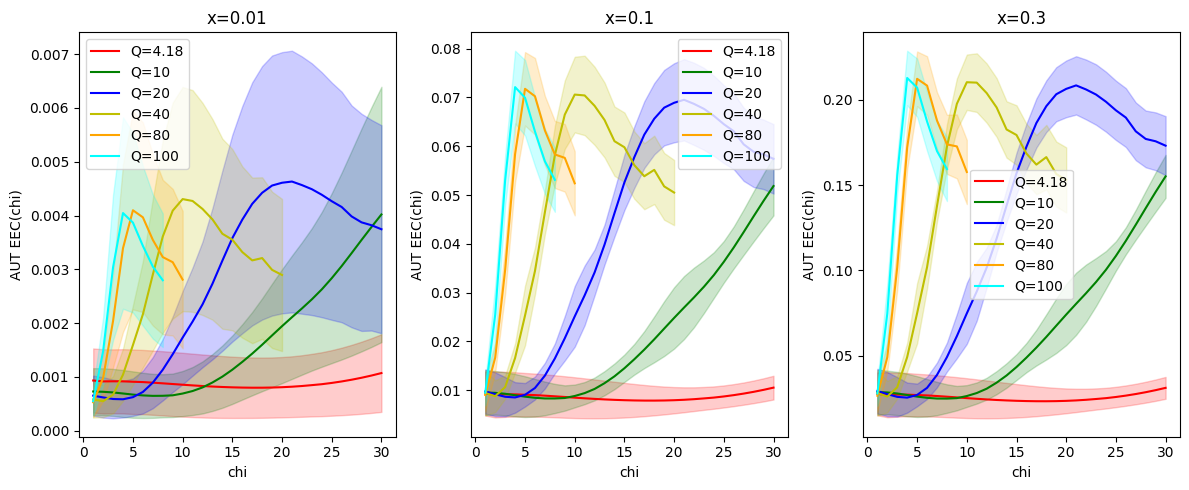

In [11]:
x_list = [0.01, 0.1, 0.3]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

plot_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.1, 0.1),
    fit_order="LO",
)


In [12]:
x_list = [0.01, 0.1, 0.3]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

generate_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.01, 0.01),
    nreps_rand=1,
    fit_order="LO",
)


done | total elapsed: 0.5s


Results for LO
a=0.01, b=0.01


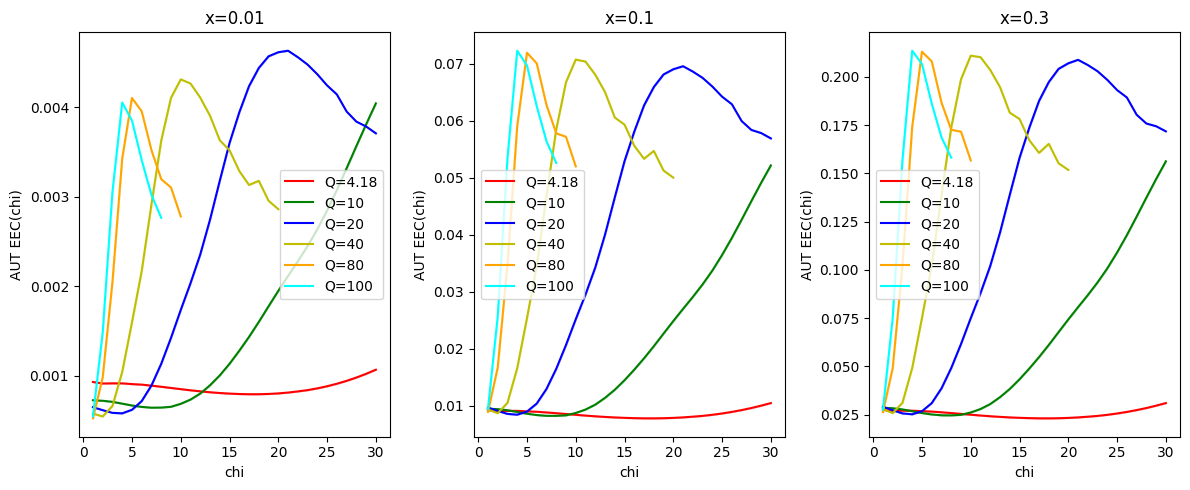

In [13]:
x_list = [0.01, 0.1, 0.3]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

plot_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.01, 0.01),
    fit_order="LO",
)


In [14]:
x_list = [0.01, 0.1, 0.3]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

generate_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(1.0, 1.0),
    nreps_rand=1,
    fit_order="LO",
)


done | total elapsed: 0.6s


Results for LO
a=1.00, b=1.00


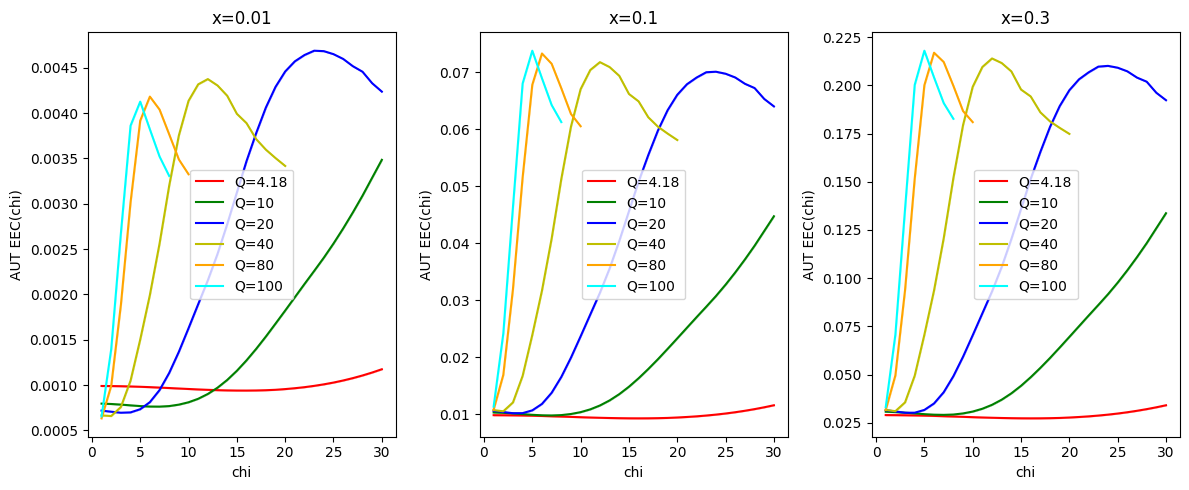

In [15]:
x_list = [0.01, 0.1, 0.3]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

plot_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(1.0, 1.0),
    fit_order="LO",
)


In [16]:
x_list = [0.3]
Q_list = [20]

generate_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.5, 0.1),
    nreps_rand=1,
    fit_order="LO",
)


done | total elapsed: 0.1s


Results for LO
a=0.50, b=0.10


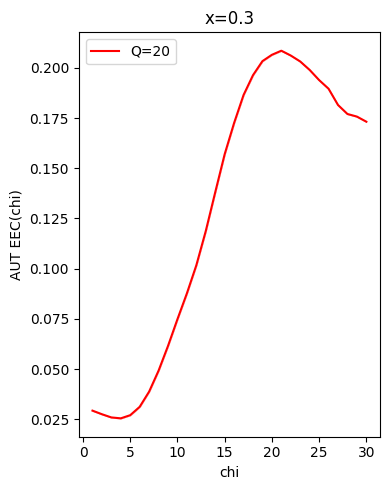

In [17]:
x_list = [0.3]
Q_list = [20]

plot_sidis_aut_results(
    x_list=x_list,
    Q_list=Q_list,
    coeffs=(0.5, 0.1),
    fit_order="LO",
)


ee EEC AUT

Test & Warm Up ee AUT

In [18]:
chibar_deg = 30.0
chi_deg = 10.0
chibar = np.deg2rad(chibar_deg)
chi = np.deg2rad(chi_deg)

set_diff_coeffs(0.1, 0.1)

value = Main.EE_EEC_AUT(
    chi=chi,
    chibar=chibar,
    Q=20.0,
    mu=10.0,
    rep=0,
)

warmup_values, warmup_time = Main.EE_EEC_AUT_pmap(
    chi_array=[chi, chi],
    chibar_array=[chibar, chibar],
    Q_array=[20.0, 20.0],
    mu_array=[10.0, 10.0],
    rep=[0, 0],
)

display(value)
display((len(warmup_values), warmup_time))


0.025865871197193354

(2, 0.129013001)

In [19]:
def ee_aut_filename(a, b, chibar_deg, Q, fit_order="LO"):
    return results_dir / f"AUT_EEC_epem_a{a:.2f}_b{b:.2f}_chibar{int(chibar_deg)}_Q{int(Q)}_{fit_order}.xlsx"


def generate_ee_aut_results(*, chibar_deg_list, Q_list, coeffs, nreps_rand, fit_order="LO", chi_deg_array=None):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")
    if chi_deg_array is None:
        chi_deg_array = np.linspace(1, 30, 30)

    nreps_rand = min(int(nreps_rand), len(all_replica_ids))
    rep_DiFF = np.asarray(np.random.choice(all_replica_ids, size=nreps_rand, replace=False), dtype=int)
    total_jobs = len(chibar_deg_list) * len(Q_list)
    jobs_done = 0
    t0_all = time.perf_counter()

    set_diff_coeffs(coeffs[0], coeffs[1])

    for chibar_deg in chibar_deg_list:
        chibar = np.deg2rad(chibar_deg)
        zbar = (1 - np.cos(chibar)) / 2

        for Q in Q_list:
            chi_deg_valid = []
            chi_valid = []
            for chi_deg in chi_deg_array:
                chi = np.deg2rad(chi_deg)
                z = (1 - np.cos(chi)) / 2
                if np.sqrt(z) * Q > 7 or np.sqrt(zbar) * Q > 7:
                    continue
                chi_deg_valid.append(float(chi_deg))
                chi_valid.append(float(chi))

            n_chi = len(chi_valid)
            chi_array = np.asarray(chi_valid, dtype=float)
            chibar_array = np.full(n_chi, float(chibar), dtype=float)
            Q_array = np.full(n_chi, float(Q), dtype=float)
            mu_array = np.full(n_chi, float(c * Q), dtype=float)

            AUT_EEC_thy_central, _ = Main.EE_EEC_AUT_pmap(
                chi_array=chi_array,
                chibar_array=chibar_array,
                Q_array=Q_array,
                mu_array=mu_array,
                rep=np.zeros(n_chi, dtype=int),
            )

            if nreps_rand > 0:
                rep_array = np.repeat(rep_DiFF, n_chi)
                chi_array_flat = np.tile(chi_array, nreps_rand)
                chibar_array_flat = np.tile(chibar_array, nreps_rand)
                Q_array_flat = np.tile(Q_array, nreps_rand)
                mu_array_flat = np.tile(mu_array, nreps_rand)

                AUT_EEC_thy_arr_flat, _ = Main.EE_EEC_AUT_pmap(
                    chi_array=chi_array_flat,
                    chibar_array=chibar_array_flat,
                    Q_array=Q_array_flat,
                    mu_array=mu_array_flat,
                    rep=rep_array,
                )
                AUT_EEC_thy_arr_all = np.asarray(AUT_EEC_thy_arr_flat, dtype=float).reshape(nreps_rand, n_chi)
                AUT_EEC_thy_std = np.std(AUT_EEC_thy_arr_all, axis=0)
            else:
                AUT_EEC_thy_std = np.zeros(n_chi, dtype=float)

            _CHI = chi_deg_valid
            AUT_EEC_thy_central = np.asarray(AUT_EEC_thy_central, dtype=float)
            jobs_done += 1
            elapsed = time.perf_counter() - t0_all
            avg_time = elapsed / jobs_done
            eta = avg_time * (total_jobs - jobs_done)
            clear_output(wait=True)
            print(f"[{jobs_done}/{total_jobs}] chibar={chibar_deg:g}, Q={Q:g} | remaining={_format_seconds(eta)}")

            df = pd.DataFrame()
            df["CHI"] = _CHI
            df["AUT_central"] = AUT_EEC_thy_central
            df["AUT_mean"] = AUT_EEC_thy_central
            df["AUT_std"] = AUT_EEC_thy_std
            df.to_excel(ee_aut_filename(coeffs[0], coeffs[1], chibar_deg, Q, fit_order), index=False)

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(f"done | total elapsed: {_format_seconds(total_elapsed)}")


def plot_ee_aut_results(*, chibar_deg_list, Q_list, coeffs, fit_order="LO"):
    print(f"Results for {fit_order}")
    print(f"a={coeffs[0]:.2f}, b={coeffs[1]:.2f}")

    nrows, ncols = 1, len(chibar_deg_list)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * len(chibar_deg_list), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, chibar_deg in enumerate(chibar_deg_list):
        ax1 = axes[ifig]
        for icol, Q in enumerate(Q_list):
            df = pd.read_excel(ee_aut_filename(coeffs[0], coeffs[1], chibar_deg, Q, fit_order))
            _CHI = np.asarray(df['CHI'], dtype=float)
            AUT_EEC_thy_central = np.asarray(df['AUT_central'] if 'AUT_central' in df else df['AUT_mean'], dtype=float)
            AUT_EEC_thy_std = np.asarray(df['AUT_std'], dtype=float)

            ax1.plot(_CHI, AUT_EEC_thy_central, color=color_arr[icol], label=f'Q={Q:g}')
            ax1.fill_between(_CHI, AUT_EEC_thy_central + AUT_EEC_thy_std, AUT_EEC_thy_central - AUT_EEC_thy_std, color=color_arr[icol], alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('AUT EEC(chi)')
        ax1.set_title(f'chibar={chibar_deg:g}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [20]:
chibar_deg_list = [1, 15, 30]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

generate_ee_aut_results(
    chibar_deg_list=chibar_deg_list,
    Q_list=Q_list,
    coeffs=(0.1, 0.1),
    nreps_rand=N_replicas,
    fit_order="LO",
)


done | total elapsed: 13.7s


Results for LO
a=0.10, b=0.10


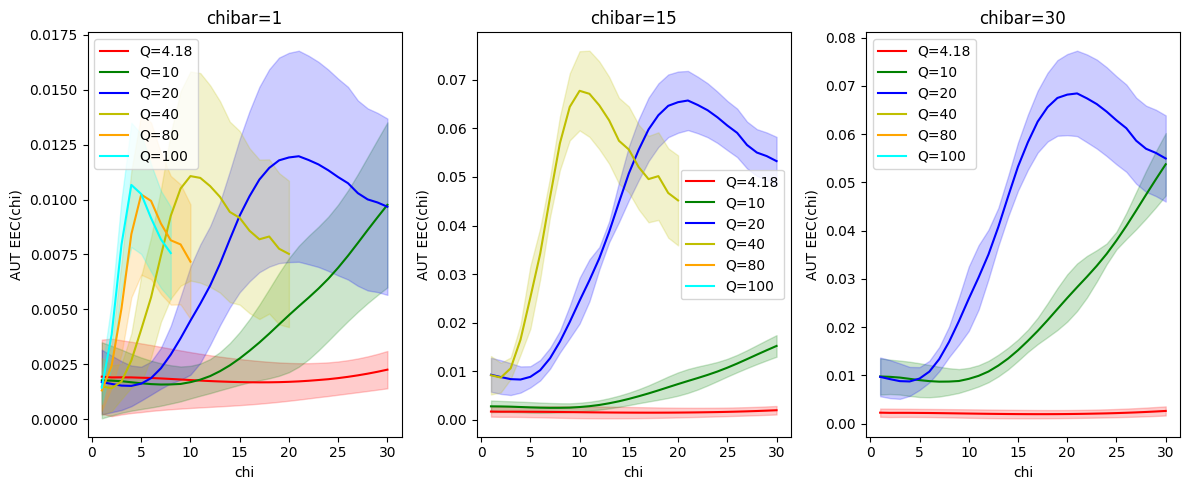

In [21]:
chibar_deg_list = [1, 15, 30]
Q_list = [float(Main.mb), 10, 20, 40, 80, 100]

plot_ee_aut_results(
    chibar_deg_list=chibar_deg_list,
    Q_list=Q_list,
    coeffs=(0.1, 0.1),
    fit_order="LO",
)
